In [1]:
import jpc
import jax.random as jr
import equinox as eqx
import equinox.nn as nn
import optax


import math 
import random
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def set_global_seed(seed):
    torch.manual_seed(seed)             
    torch.cuda.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)        
    np.random.seed(seed)                  
    random.seed(seed)                       
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False

In [2]:
SEED = 4329

INPUT_DIM = 784
WIDTH = 128
DEPTH = 30
OUTPUT_DIM = 10
ACT_FN = "relu"

ACTIVITY_LR = 5e-1
PARAM_LR = 1e-1
BATCH_SIZE = 64
TEST_EVERY = 100
N_TRAIN_ITERS = 900

In [3]:
def get_mnist_dataloaders(batch_size=BATCH_SIZE):
    train_data = MNIST(train= True, normalise = True)
    test_data = MNIST(train= False, normalise = True)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, test_loader
    
    
class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.1307, 0.3081)])
        else:
            transform = transforms.Compose([transforms.ToTensor()])

        super().__init__(save_dir, download=True, train=train, transform=transform) 

    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        img = img.view(-1)  # flatten the image
        label = one_hot(target)
        return img, label

def one_hot(label, num_classes=10):
    arr = torch.eye(num_classes)
    return arr[label]

## Creating a mu-PC model

In [4]:
key = jr.PRNGKey(SEED)

#MLP 
model = jpc.make_mlp(key, INPUT_DIM, WIDTH, DEPTH, OUTPUT_DIM,ACT_FN, param_type="mupc")

skip_model = jpc.make_skip_model(DEPTH)

print(model, skip_model)

[Sequential(
  layers=(
    Lambda(fn=Identity()),
    Linear(
      weight=f32[128,784],
      bias=None,
      in_features=784,
      out_features=128,
      use_bias=False
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>),
    Linear(
      weight=f32[128,128],
      bias=None,
      in_features=128,
      out_features=128,
      use_bias=False
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>),
    Linear(
      weight=f32[128,128],
      bias=None,
      in_features=128,
      out_features=128,
      use_bias=False
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>),
    Linear(
      weight=f32[128,128],
      bias=None,
      in_features=128,
      out_features=128,
      use_bias=False
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>),
    Linear(
      weight=f32[128,128]

In [5]:
from typing import List
from typing import Callable
class ScaledLinear(eqx.Module):
    "Scaled Linear tranformations"
    linear:nn.Linear
    scaling:float = eqx.static_field()

    def __init__(self, in_features, out_features, *, key, scaling=1, param_type="sp", use_bias=True ):
        keys = jr.split(key, 2)
        linear = nn.Linear(in_features, out_features,use_bias=use_bias, key=keys[0])
        if param_type == "mupc":
            W = jr.normal(keys[1], linear.weight.shape) # Scale hidden weights by (Nl-1 * L) power 1/2
            linear = eqx.tree_at(lambda l: l.weight, linear, W)

        self.linear = linear
        self.scaling = scaling

    def __call__(self, x):
        return self.scaling * self.linear(x)



class ResNetBlock(eqx.Module):
    "Identity residual blaock scaled linear block"
    scaled_linear: ScaledLinear
    act_fn: Callable = eqx.static_field()

    def __init__(self, in_features, out_features, *, key, scaling=1, param_type="sp", use_bias=True, act_fn="linear"):
        self.act_fn = act_fn
        self.scaled_linear = ScaledLinear(
            in_features,
            out_features,
            key=key,
            scaling=scaling,
            param_type=param_type,
            use_bias = use_bias
        )


    def __call__(self, x):
        res = x
        x = self.act_fn(x)
        return self.scaled_linear(x) + res


class Readout(eqx.Module):
    "Final layer which runs the act_fn and linear layer"
    scaled_linear: ScaledLinear
    act_fn: Callable = eqx.static_field()

    def __init__(self, in_features, out_features, *, key, scaling=1, param_type="sp", use_bias=True, act_fn="linear"):
        self.act_fn = act_fn
        self.scaled_linear = ScaledLinear(
            in_features,
            out_features,
            key=key,
            scaling=scaling,
            param_type=param_type,
            use_bias = use_bias
        )


    def __call__(self, x):
        x = self.act_fn(x)
        return self.scaled_linear(x) 


class FCResnet(eqx.Module):
    "Fully connected Resnet compatible with different parametrisations"
    layers: List[eqx.Module]
    def __init__(self, key,in_dim, out_dim, *, width,depth, act_fn="linear", use_bias=False, param_type="sp"):
        act_fn = jpc.get_act_fn(act_fn)
        if param_type == "sp":
            in_scaling = 1
            hidden_scaling = 1
            out_scaling = 1
        if param_type == "mupc": # Exact parameterization from the paper
            in_scaling = 1 / math.sqrt(in_dim)
            hidden_scaling = 1 / math.sqrt(width * depth)
            out_scaling = 1 / width


        keys = jr.split(key, depth) # Splitting seed for each layer for reproducaibility

        self.layers = [ScaledLinear(
                key=keys[0],
                in_features=in_dim,
                out_features=width,
                scaling=in_scaling,
                param_type=param_type,
                use_bias=use_bias
            )]

        for i in range(1, depth - 1):
            self.layers.append(ResNetBlock(
                width,
                width,
                key=keys[i],
                scaling=hidden_scaling,
                param_type=param_type,
                use_bias=use_bias,
                act_fn=act_fn
            ))

        self.layers.append(Readout(
            width,
            out_dim,
            key=keys[-1],
            scaling=out_scaling,
            param_type=param_type,
            use_bias=use_bias,
            act_fn=act_fn
        ))


    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def __len__(self):
        return len(self.layers)

    def __getitem__(self, idx):
        return self.layers[idx]



In [6]:
mupc_model = FCResnet(
    key=key, 
    in_dim=INPUT_DIM, 
    width=WIDTH, 
    depth=DEPTH, 
    out_dim=OUTPUT_DIM, 
    act_fn=ACT_FN, 
    use_bias=False, 
    param_type="mupc"
)
print(mupc_model)

FCResnet(
  layers=[
    ScaledLinear(
      linear=Linear(
        weight=f32[128,784],
        bias=None,
        in_features=784,
        out_features=128,
        use_bias=False
      ),
      scaling=0.03571428571428571
    ),
    ResNetBlock(
      scaled_linear=ScaledLinear(
        linear=Linear(
          weight=f32[128,128],
          bias=None,
          in_features=128,
          out_features=128,
          use_bias=False
        ),
        scaling=0.01613743060919757
      ),
      act_fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>
    ),
    ResNetBlock(
      scaled_linear=ScaledLinear(
        linear=Linear(
          weight=f32[128,128],
          bias=None,
          in_features=128,
          out_features=128,
          use_bias=False
        ),
        scaling=0.01613743060919757
      ),
      act_fn=<PjitFunction of <function relu at 0x7fc948d31dd0>>
    ),
    ResNetBlock(
      scaled_linear=ScaledLinear(
        linear=Linear(
          weight=f32[128,1

In [7]:
def evaluate(model, skip_model, test_loader, param_type):
    avg_test_acc = 0
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        _, test_acc = jpc.test_discriminative_pc(
            model=model,
            input=img_batch,
            output=label_batch,
            skip_model=skip_model,
            param_type=param_type
        )
        avg_test_acc += test_acc

    return avg_test_acc / len(test_loader)

In [8]:
def train(seed, model, skip_model, param_type, activity_lr, param_lr, batch_size, test_every, n_train_iters):
    set_global_seed(seed)
    activity_optim = optax.sgd(activity_lr)
    param_optim = optax.adam(param_lr)
    param_opt_state  = param_optim.init((eqx.filter(model, eqx.is_array), skip_model))
    train_loader, test_loader = get_mnist_dataloaders(batch_size)

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        #init activities
        activities = jpc.init_activities_with_ffwd(model, img_batch, skip_model=skip_model, param_type=param_type)
        activity_opt_state = activity_optim.init(activities)
        train_loss = jpc.mse_loss(activities[-1], label_batch)

        # Inference
        for t in range(len(model)):
            activity_update_result = jpc.update_pc_activities(params=(model, skip_model), activities=activities, optim= activity_optim, opt_state=activity_opt_state,output=label_batch,input=img_batch, param_type=param_type)
            activities = activity_update_result["activities"]
            activity_opt_state = activity_update_result["opt_state"]

        #learning
        param_update_result = jpc.update_pc_params(params=(model, skip_model), activities=activities, optim=param_optim, opt_state=param_opt_state,output=label_batch,input=img_batch, param_type=param_type)
        model = param_update_result["model"]
        skip_model = param_update_result["skip_model"]
        param_opt_state = param_update_result["opt_state"]

        if np.isinf(train_loss) or np.isnan(train_loss):
            print(
                f"Stopping training because of divergence, train loss={train_loss}"
            )
            break


        if ((iter+1) % test_every) == 0:
            avg_test_acc = evaluate(
                model=model,
                skip_model=skip_model, 
                test_loader=test_loader, 
                param_type=param_type
            )
            print(
                f"Train iter {iter+1}, train loss={train_loss:4f}, "
                f"avg test accuracy={avg_test_acc:4f}"
            )
            if (iter+1) >= n_train_iters:
                break

In [9]:
train(
    seed=SEED,
    model=model,
    skip_model=skip_model,
    param_type="mupc",
    activity_lr=ACTIVITY_LR,
    param_lr=PARAM_LR,
    batch_size=BATCH_SIZE,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

Train iter 100, train loss=0.161313, avg test accuracy=85.927551
Train iter 200, train loss=0.120723, avg test accuracy=88.823647
Train iter 300, train loss=0.098292, avg test accuracy=90.595146
Train iter 400, train loss=0.091671, avg test accuracy=91.301750
Train iter 500, train loss=0.111068, avg test accuracy=92.366638
Train iter 600, train loss=0.089867, avg test accuracy=92.008362
Train iter 700, train loss=0.068624, avg test accuracy=93.033440
Train iter 800, train loss=0.089616, avg test accuracy=93.411629
Train iter 900, train loss=0.085307, avg test accuracy=93.660431


---
# Diagnostics and baselines

The run above shows that muPC *works*. These cells test *why*, using the same
instruments the paper uses:

| cell | what it tests | paper reference |
|---|---|---|
| forward-pass norms | Desideratum 1 (stable forward pass at init) | Sec. 4, Fig. A.30 |
| SP control at DEPTH=30 | that muPC is doing the work, not the hyperparameters | Sec. 3.2 |
| energy trace over inference | is T = depth enough relaxation? | Sec. A.3.5 |
| activity norms over training | Desideratum 2 (stability *during* training) | Sec. 4 |
| depth sweep | does the muPC advantage grow with depth? | Fig. 1 |


 layer       muPC           SP
     1     10.845        6.283
     2     10.927        6.759
    16     12.094       22.152
    29     13.176       60.357
    30      0.199        8.557

drift (last hidden / first hidden):  muPC 1.21x   SP 9.61x


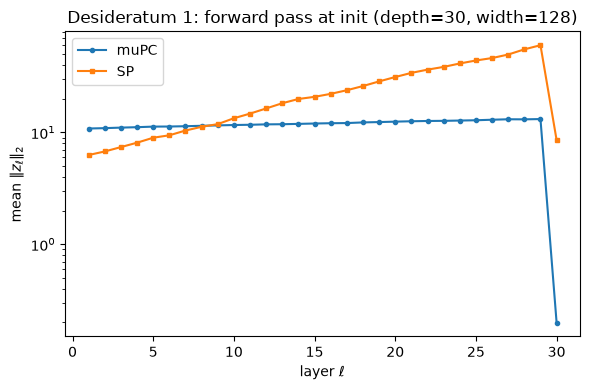

In [10]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ---------------------------------------------------------------- Desideratum 1
# ||z_l|| should be O(1) in width AND depth, i.e. flat across layers.
# muPC guarantees this by construction; SP does not.

def act_norms_at_init(depth, width=WIDTH, in_dim=INPUT_DIM, out_dim=OUTPUT_DIM,
                      act_fn=ACT_FN, key=key, batch=None):
    """Mean L2 norm of each layer's activities after a forward pass."""
    if batch is None:
        batch = np.asarray(next(iter(get_mnist_dataloaders(32)[0]))[0])
    out = {}
    for pt in ("mupc", "sp"):
        m = jpc.make_mlp(key, in_dim, width, depth, out_dim, act_fn, param_type=pt)
        sk = jpc.make_skip_model(depth)
        a = jpc.init_activities_with_ffwd(m, batch, skip_model=sk, param_type=pt)
        out[pt] = np.array([float(jnp.linalg.norm(z, axis=-1).mean()) for z in a])
    return out

norms = act_norms_at_init(DEPTH)
print(f"{'layer':>6} {'muPC':>10} {'SP':>12}")
for l in [0, 1, DEPTH // 2, DEPTH - 2, DEPTH - 1]:
    print(f"{l+1:>6} {norms['mupc'][l]:>10.3f} {norms['sp'][l]:>12.3f}")
print(f"\ndrift (last hidden / first hidden):  "
      f"muPC {norms['mupc'][-2]/norms['mupc'][0]:.2f}x   "
      f"SP {norms['sp'][-2]/norms['sp'][0]:.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, DEPTH + 1), norms["mupc"], "o-", ms=3, label="muPC")
ax.plot(range(1, DEPTH + 1), norms["sp"], "s-", ms=3, label="SP")
ax.set_yscale("log"); ax.set_xlabel("layer $\\ell$")
ax.set_ylabel(r"mean $\|z_\ell\|_2$")
ax.set_title(f"Desideratum 1: forward pass at init (depth={DEPTH}, width={WIDTH})")
ax.legend(); fig.tight_layout()

In [11]:
# ------------------------------------------------- instrumented training loop
# Same algorithm as train() above, but records diagnostics and RETURNS them.
# Note: jpc has compute_infer_energies(), but it expects diffrax-style
# activities_iters; for the discrete loop we call pc_energy_fn directly.

def train_diag(seed, model, skip_model, param_type, activity_lr=ACTIVITY_LR,
               param_lr=PARAM_LR, batch_size=BATCH_SIZE, test_every=TEST_EVERY,
               n_train_iters=N_TRAIN_ITERS, n_test_batches=30, verbose=True):
    set_global_seed(seed)
    activity_optim = optax.sgd(activity_lr)
    param_optim = optax.adam(param_lr)
    param_opt_state = param_optim.init((eqx.filter(model, eqx.is_array), skip_model))
    train_loader, test_loader = get_mnist_dataloaders(batch_size)
    T = len(model)

    h = {"iter": [], "train_loss": [], "test_acc": [], "energy_trace": [],
         "act_norms": [], "param_norm": [], "diverged": False,
         "param_type": param_type, "depth": T}

    for it, (img, lab) in enumerate(train_loader):
        img, lab = img.numpy(), lab.numpy()
        log = ((it + 1) % test_every) == 0

        activities = jpc.init_activities_with_ffwd(
            model, img, skip_model=skip_model, param_type=param_type)
        activity_opt_state = activity_optim.init(activities)
        train_loss = float(jpc.mse_loss(activities[-1], lab))

        energy = lambda a: float(jpc.pc_energy_fn(
            (model, skip_model), a, lab, x=img, param_type=param_type))
        trace = [energy(activities)] if log else []

        # inference: T = depth steps of GD on the activities (Eq. 2)
        for t in range(T):
            r = jpc.update_pc_activities(
                params=(model, skip_model), activities=activities,
                optim=activity_optim, opt_state=activity_opt_state,
                output=lab, input=img, param_type=param_type)
            activities, activity_opt_state = r["activities"], r["opt_state"]
            if log:
                trace.append(energy(activities))

        # learning
        r = jpc.update_pc_params(
            params=(model, skip_model), activities=activities,
            optim=param_optim, opt_state=param_opt_state,
            output=lab, input=img, param_type=param_type)
        model, skip_model = r["model"], r["skip_model"]
        param_opt_state = r["opt_state"]

        if not np.isfinite(train_loss):
            h["diverged"] = True
            if verbose:
                print(f"  diverged at iter {it+1}, train loss={train_loss}")
            break

        if log:
            # sample-weighted accuracy (avoids bias from the short last batch)
            correct = total = 0
            for j, (ti, tl) in enumerate(test_loader):
                if j >= n_test_batches:
                    break
                _, acc = jpc.test_discriminative_pc(
                    model=model, input=ti.numpy(), output=tl.numpy(),
                    skip_model=skip_model, param_type=param_type)
                correct += float(acc) * len(tl); total += len(tl)

            h["iter"].append(it + 1)
            h["train_loss"].append(train_loss)
            h["test_acc"].append(correct / total)
            h["energy_trace"].append(trace)
            h["act_norms"].append(np.array(jpc.compute_activity_norms(activities)))
            h["param_norm"].append(float(jnp.linalg.norm(
                jpc.compute_param_norms((model, skip_model))[0])))
            if verbose:
                print(f"  iter {it+1:>4}  loss={train_loss:.4f}  "
                      f"acc={correct/total:.2f}%  F(z_0)={trace[0]:.4f}  "
                      f"F(z_T)={trace[-1]:.4f}  ||W||={h['param_norm'][-1]:.2f}")

        if (it + 1) >= n_train_iters:
            break

    return h, model, skip_model

In [12]:
# ------------------------------------------------------- the SP control
# The claim "muPC trains 30 layers" only means something next to this.
# Expect: chance accuracy (~10%) and/or an exploding inference energy.

hist = {}

print("muPC, depth", DEPTH)
hist["mupc"], mupc_trained, mupc_skip = train_diag(
    SEED, jpc.make_mlp(key, INPUT_DIM, WIDTH, DEPTH, OUTPUT_DIM, ACT_FN,
                       param_type="mupc"),
    jpc.make_skip_model(DEPTH), "mupc")

print("\nSP, depth", DEPTH)
hist["sp"], _, _ = train_diag(
    SEED, jpc.make_mlp(key, INPUT_DIM, WIDTH, DEPTH, OUTPUT_DIM, ACT_FN,
                       param_type="sp"),
    jpc.make_skip_model(DEPTH), "sp")

print(f"\nfinal test acc:  muPC {hist['mupc']['test_acc'][-1]:.2f}%   "
      f"SP {hist['sp']['test_acc'][-1]:.2f}%")

muPC, depth 30
  iter  100  loss=0.1613  acc=82.03%  F(z_0)=0.1613  F(z_T)=0.1605  ||W||=810.77
  iter  200  loss=0.1207  acc=84.64%  F(z_0)=0.1207  F(z_T)=0.1201  ||W||=860.10
  iter  300  loss=0.0983  acc=86.61%  F(z_0)=0.0983  F(z_T)=0.0978  ||W||=897.59
  iter  400  loss=0.0917  acc=88.07%  F(z_0)=0.0917  F(z_T)=0.0912  ||W||=929.06
  iter  500  loss=0.1111  acc=89.43%  F(z_0)=0.1111  F(z_T)=0.1105  ||W||=965.57
  iter  600  loss=0.0899  acc=89.01%  F(z_0)=0.0899  F(z_T)=0.0893  ||W||=998.47
  iter  700  loss=0.0686  acc=90.16%  F(z_0)=0.0686  F(z_T)=0.0681  ||W||=1034.97
  iter  800  loss=0.0896  acc=91.20%  F(z_0)=0.0896  F(z_T)=0.0889  ||W||=1070.87
  iter  900  loss=0.0853  acc=91.41%  F(z_0)=0.0853  F(z_T)=0.0847  ||W||=1098.57

SP, depth 30
  diverged at iter 8, train loss=inf


IndexError: list index out of range

In [ ]:
# ------------------------------- is T = depth enough inference? (Sec. A.3.5)
# Each curve is the PC energy F(z) across the T relaxation steps of ONE
# training iteration. Flat-from-the-start => the forward pass already landed
# near z*, which is muPC's mechanism for tolerating a badly-conditioned
# inference landscape (Sec. 3.1 / Desideratum 3).

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pt in zip(axes, ["mupc", "sp"]):
    h = hist[pt]
    for i, trace in enumerate(h["energy_trace"]):
        if not trace:
            continue
        ax.plot(range(len(trace)), trace, alpha=0.75,
                label=f"iter {h['iter'][i]}")
    ax.set_yscale("log"); ax.set_xlabel("inference step $t$")
    ax.set_ylabel("$F(z)$"); ax.set_title(f"{pt}: energy during inference")
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

h = hist["mupc"]
print("muPC: relative energy drop over the T inference steps")
for i, tr in enumerate(h["energy_trace"]):
    if tr:
        print(f"  iter {h['iter'][i]:>4}:  F(z_0)={tr[0]:.5f} -> "
              f"F(z_T)={tr[-1]:.5f}   drop={100*(1-tr[-1]/tr[0]):.3f}%")

In [ ]:
# ------------------------------ Desideratum 2: stability DURING training
# Desideratum 1 is an initialisation statement. The paper says plainly that
# it does not know whether Depth-muP keeps it true during training for PC.
# Left panel answers that empirically for this run.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
h = hist["mupc"]
cmap = plt.cm.viridis(np.linspace(0, 1, len(h["act_norms"])))
for c, it_, nrm in zip(cmap, h["iter"], h["act_norms"]):
    axes[0].plot(range(1, len(nrm) + 1), nrm, color=c, label=f"iter {it_}")
axes[0].set_xlabel("layer $\\ell$"); axes[0].set_ylabel(r"$\|z_\ell\|_2$")
axes[0].set_yscale("log")
axes[0].set_title("muPC: activity norms per layer over training")
axes[0].legend(fontsize=7, ncol=2)

axes[1].plot(h["iter"], h["param_norm"], "o-", ms=4)
axes[1].set_xlabel("training iteration"); axes[1].set_ylabel(r"$\|\theta\|_2$")
axes[1].set_title("muPC: weight norm over training")
fig.tight_layout()

In [ ]:
# -------------------------------------------------------- depth sweep (Fig. 1)
# Fixed width, growing depth. muPC should hold up; SP should degrade with depth.
# Cost per iteration grows with depth (T = depth inference steps), so this uses
# fewer iterations than the main run. Expect a few minutes on CPU.

DEPTHS = [8, 16, 30, 64]
SWEEP_ITERS = 300
SWEEP_TEST_EVERY = 100

sweep = {}
for pt in ["mupc", "sp"]:
    for D in DEPTHS:
        print(f"{pt}, depth {D}")
        h, _, _ = train_diag(
            SEED,
            jpc.make_mlp(key, INPUT_DIM, WIDTH, D, OUTPUT_DIM, ACT_FN, param_type=pt),
            jpc.make_skip_model(D), pt,
            test_every=SWEEP_TEST_EVERY, n_train_iters=SWEEP_ITERS,
            n_test_batches=20, verbose=False)
        sweep[(pt, D)] = h
        acc = h["test_acc"][-1] if h["test_acc"] else float("nan")
        print(f"    final acc {acc:.2f}%   diverged={h['diverged']}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for pt, mk in [("mupc", "o-"), ("sp", "s--")]:
    accs = [sweep[(pt, D)]["test_acc"][-1] if sweep[(pt, D)]["test_acc"]
            else float("nan") for D in DEPTHS]
    axes[0].plot(DEPTHS, accs, mk, label=pt)
axes[0].axhline(10, color="grey", ls=":", lw=1)
axes[0].annotate("chance", (DEPTHS[0], 11), fontsize=8, color="grey")
axes[0].set_xlabel("depth"); axes[0].set_ylabel(f"test accuracy (%) @ {SWEEP_ITERS} iters")
axes[0].set_title("Learning-rate transfer across depth"); axes[0].legend()

for pt, mk in [("mupc", "o-"), ("sp", "s--")]:
    for D in DEPTHS:
        h = sweep[(pt, D)]
        if h["test_acc"]:
            axes[1].plot(h["iter"], h["test_acc"], mk, ms=3, alpha=0.8,
                         label=f"{pt} d={D}")
axes[1].set_xlabel("training iteration"); axes[1].set_ylabel("test accuracy (%)")
axes[1].set_title("Training curves"); axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout()

print(f"{'depth':>6} {'muPC':>10} {'SP':>10}")
for D in DEPTHS:
    a = sweep[("mupc", D)]["test_acc"]; b = sweep[("sp", D)]["test_acc"]
    print(f"{D:>6} {(a[-1] if a else float('nan')):>10.2f} "
          f"{(b[-1] if b else float('nan')):>10.2f}")

In [ ]:
# ---------------------- sanity check: is FCResnet the same net as make_mlp?
# Cell 6 builds mupc_model but never trains or verifies it. Before extending
# FCResnet (CNNs, a JEPA predictor), confirm it matches the library model.
# Copy weights across, then the two forward passes must agree.

mupc_model = FCResnet(key=key, in_dim=INPUT_DIM, out_dim=OUTPUT_DIM, width=WIDTH,
                      depth=DEPTH, act_fn=ACT_FN, use_bias=False, param_type="mupc")
mupc_model = eqx.tree_at(lambda tree: tree[0].linear.weight, mupc_model,
                         model[0][1].weight)
for l in range(1, len(model)):
    mupc_model = eqx.tree_at(
        lambda tree, l=l: tree[l].scaled_linear.linear.weight,
        mupc_model, model[l][1].weight)

img_batch = np.asarray(next(iter(get_mnist_dataloaders(BATCH_SIZE)[0]))[0])
a_lib = jpc.init_activities_with_ffwd(model, img_batch,
                                     skip_model=skip_model, param_type="mupc")
a_own = jpc.init_activities_with_ffwd(mupc_model, img_batch,
                                     skip_model=None, param_type="sp")
print("max |diff| per layer:",
      max(float(jnp.abs(u - v).max()) for u, v in zip(a_lib, a_own)))
print("output max |diff|:  ", float(jnp.abs(a_lib[-1] - a_own[-1]).max()))
# ~0 means FCResnet reproduces make_mlp(param_type='mupc') exactly.
# Then this trains identically to the run above:
# train(seed=SEED, model=mupc_model, skip_model=None, param_type="sp", ...)